# Refraction Seismic Tomography (RST) Inversion & Visualization
Performs P-wave velocity ($v_p$) inversion on traveltime data (`*_tt.txt`) and topography (`*_topo.txt`) using pyGIMLi.

In [1]:
# %% Imports and Environment Setup
import importlib
import os
import sys
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygimli as pg
import pygimli.physics.traveltime as tt

# Close any open plots
plt.close("all")

In [3]:
# Target profile (matches the filename prefix without extension)
profile = "BUL01_2023-08-07_2m"

# 1. Dynamically locate repository root (works regardless of cwd or cell re-runs)
current_path = Path.cwd().resolve()
repo_root = None

for parent in [current_path] + list(current_path.parents):
    if (
        parent / ".git"
    ).exists() or parent.name == "central-asia-permafrost-geophysics":
        repo_root = parent
        break

if repo_root is None:
    raise FileNotFoundError("Could not locate repository root directory!")

# 2. Build relative paths from the repository root
base_data_path = (
    repo_root / "data" / "geophysics" / "raw" / "002_RST" / "002_udf"
)
topo_path = repo_root / "data" / "geophysics" / "raw" / "002_RST" / "004_topo"
figures_dir = repo_root / "figures"
path_settings = repo_root / "scripts" / "field_case"

# Ensure output figures directory exists
figures_dir.mkdir(parents=True, exist_ok=True)

# Change active working directory to data path for pyGIMLi relative C++ file loading
os.chdir(base_data_path)

# Extract simple profile title
profile_title = profile.split("_")[0]


print(f"✓ Target Profile:      {profile}")

✓ Target Profile:      BUL01_2023-08-07_2m


In [4]:
# %% Inversion Parameters Configuration
# Seismic traveltime error estimate
rste = 0.0007

# Velocity gradient bounds for starting model
vTop = 300  # Velocity at surface (m/s)
vBottom = 12000  # Velocity at depth (m/s)

# Mesh & Inversion regularization parameters
paraMaxCellSize = 5.0  # Max cell size in parametric region (m²)
zWeight = 0.5  # Relative weight for vertical boundaries
secNodes = 3  # Secondary nodes for forward operator accuracy
paraDepth = 50.0  # Max depth of parametric domain (m)
lam = 3.0  # Regularization parameter (lambda)
maxIter = 15  # Max inversion iterations

# Plot colorbar and axis limits
cMins = 300  # Min velocity (m/s)
cMaxs = 3500  # Max velocity (m/s)
ylimmin = -30  # Lower y-axis limit (m)

In [5]:
# %% Load Traveltime and Topography Data
file_tt = f"{profile}_tt.txt"
file_topo = topo_path / f"{profile}_topo.txt"

# Fallback for alternative topography file naming convention if needed
if not file_topo.exists():
    file_topo_alt = topo_path / f"{profile}_topo_RST_Gimli.txt"
    if file_topo_alt.exists():
        file_topo = file_topo_alt

if not Path(file_tt).exists():
    raise FileNotFoundError(
        f"Traveltime file '{file_tt}' not found in {os.getcwd()}"
    )

# 1. Load traveltime dataset using pyGIMLi relative path
data = tt.load(file_tt)
print("Original dataset:", data)

# 2. Filter out zero traveltime measurements (source and receiver at same location)
data.remove(data["s"] == data["g"])
print("Filtered dataset (s != g):", data)

# 3. Set custom data error
data.set("err", pg.Vector(data.size(), rste))

# 4. Load topography data if available
if file_topo.exists():
    topo = np.loadtxt(file_topo)
    topo_max = np.max(topo[:, 1])
    z_new = topo[:, 1] - topo_max
    print(f"✓ Loaded topography ({file_topo.name}): {len(topo)} points")
else:
    print(
        f"! Topography file '{file_topo.name}' not found. Proceeding with flat ground."
    )

Original dataset: Data: Sensors: 51 data: 234, nonzero entries: ['g', 's', 't', 'valid']
Filtered dataset (s != g): Data: Sensors: 51 data: 234, nonzero entries: ['g', 's', 't', 'valid']
✓ Loaded topography (BUL01_2023-08-07_2m_topo_RST_Gimli.txt): 51 points


In [6]:
# %% Initialize Traveltime Manager and Run Inversion
mgr = tt.TravelTimeManager(data)

print("\n--- Starting RST Inversion ---")
print(f"Initial Velocity Range: vTop={vTop} m/s | vBottom={vBottom} m/s")

# Execute inversion
inv = mgr.invert(
    secNodes=secNodes,
    paraMaxCellSize=paraMaxCellSize,
    paraDepth=paraDepth,
    quality=33.6,
    zWeight=zWeight,
    vTop=vTop,
    vBottom=vBottom,
    lam=lam,
    maxIter=maxIter,
    verbose=1,
)

chi2_val = mgr.inv.chi2()
rms_val = mgr.inv.relrms()

print("\n--- Inversion Results ---")
print(f"Chi²:      {chi2_val:.2f}")
print(f"RMS Error: {rms_val:.2f}%")

27/07/26 - 10:55:43 - pyGIMLi - INFO - Found 1 regions.
27/07/26 - 10:55:43 - pyGIMLi - INFO - Found 1 regions.
27/07/26 - 10:55:43 - pyGIMLi - INFO - Creating forward mesh from region infos.
27/07/26 - 10:55:43 - pyGIMLi - INFO - Creating refined mesh (secnodes: 3) to solve forward task.
27/07/26 - 10:55:43 - pyGIMLi - INFO - Create gradient starting model. 300: 12000



--- Starting RST Inversion ---
Initial Velocity Range: vTop=300 m/s | vBottom=12000 m/s


27/07/26 - 10:55:43 - pyGIMLi - INFO - Created startmodel from forward operator:1613, min/max=0.000083/0.003333
27/07/26 - 10:55:43 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x0000027D8171E4D0>
Data transformation: Identity transform
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 2.5e-04/0.05
min/max (error): 1.31%/280%
min/max (start model): 8.3e-05/0.0033
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  161.47
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   12.40 (dPhi = 92.20%) lam: 3.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    9.25 (dPhi = 25.48%) lam: 3.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    7.00 (dPhi = 24.12%) lam: 3.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    5.85 (dPhi = 16.28%) lam: 3.0
-----------

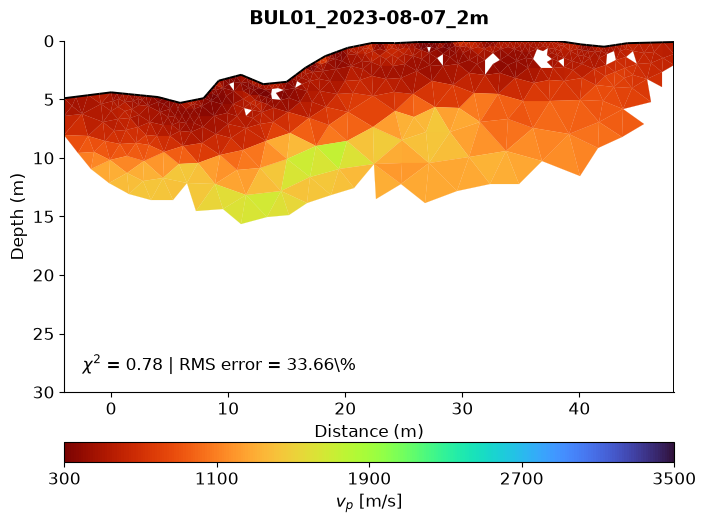

In [11]:
# %% Cell 7: Plot and Save Tomogram (Single Figure Output)
from IPython.display import display

# 1. Create a single figure instance
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Pass BOTH fig and ax to showResult to prevent pyGIMLi from creating a second figure
ax, cBar = mgr.showResult(
    inv,  # resinv for ERT, inv for RST
    fig=fig,
    ax=ax,
    cMin=cMins if "cMins" in locals() else 300,
    cMax=cMaxs if "cMaxs" in locals() else 3500,
    logScale=False,
    cMap="turbo_r",
    coverage=mgr.standardizedCoverage(),
)

# 3. Axis & Colorbar Formatting
if cBar is not None:
    cBar.set_label(r"$v_p$ [m/s]", fontsize=12)
    cBar.ax.tick_params(labelsize=12)

ax.set_xlabel("Distance (m)", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)

# Profile name as main title
ax.set_title(profile, fontsize=14, fontweight="bold", pad=12)

# Clean up borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

if "ylimmin" in locals() and ylimmin is not None:
    ax.set_ylim(bottom=ylimmin)

# Extract Chi2 and RMS values
chi2_val = mgr.inv.chi2()
rms_val = mgr.inv.relrms()

# Format LaTeX text in lower-left corner
tex_error_text = f"$\\chi^2$ = {chi2_val:.2f} | RMS error = {rms_val:.2f}\\%"

ax.text(
    0.03,
    0.05,
    tex_error_text,
    fontsize=12,
    transform=ax.transAxes,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.8,
        edgecolor="none",
    ),
)

# 4. Save output file
fig_output = figures_dir / f"{profile}_rst.png"
fig.savefig(fig_output, bbox_inches="tight", dpi=300)


# 5. Display the single finalized figure and close figure memory handle
display(fig)
plt.close(fig)

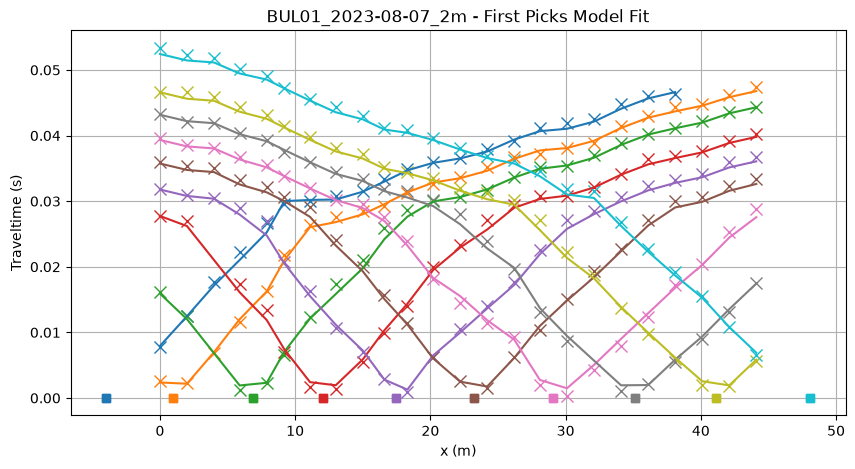

In [10]:
# %% Plot and Save Traveltime First Picks Fit
fig_fit, ax_fit = plt.subplots(figsize=(10, 5))

# Plot measured picks vs inverted model response
ax_fit, cbar_fit = mgr.showData(ax=ax_fit, firstPicks=True, linewidth=0)
tt.drawFirstPicks(ax_fit, data, mgr.inv.response, marker=None)

ax_fit.set_title(f"{profile} - First Picks Model Fit", fontsize=12)

fit_output = figures_dir / f"{profile}_rst_modelfit.png"
fig_fit.savefig(fit_output, bbox_inches="tight", dpi=300)


display(fig_fit)
plt.close(fig_fit)